# Power System Simulation Package

**Final Presentation – Power System Computation and Simulation**

Team: *Power_Flow*  
Members: *Christina Vaintirli, Christo Christozov, Emir Terzier, Mehmet Kizildenizli, Yigit Delmen*

---

## Presentation Structure

1. Project overview  
2. Assignment 1 & 2  
3. EV analysis  
4. N-1 analysis  
5. Tap optimization  
6. Collaboration and conclusions


# 1. Project Overview

**Presenter:** *Yigit*

## Goal of the project

Briefly explain the purpose of the package:

- Build a Python package for power system analysis
- Use software engineering practices: Git, testing, documentation, packaging
- Demonstrate power system analysis functionality on realistic scenarios

## Package overview

Describe the main modules and how they connect.


In [3]:
# Basic imports used throughout the presentation

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import Markdown, display

# Import package modules
from power_grid_model import ComponentType
from power_system_simulation import PowerSystemCase
from power_system_simulation.power_flow_processing import read_pgm_json, read_load_profile
from power_system_simulation.tap_optimization import optimize_tap_position


In [4]:
# Package/Module structure


# 2. Assignment 1 & 2

**Presenter:** *Christina*

## Assignment 1: Graph processing

- Downstream vertex detection
- Alternative edge detection
- Handling radial and meshed networks

## Assignment 2: Power flow result processing

- Processing power flow output
- Summarizing branch/node results
- Returning DataFrames


In [5]:
# Assignment 1 demo placeholder

# - Example graph
# - Run graph processing functions
# - Show result
# - We can do this live or pre-run/load it so we only show the results (second option safer)

In [6]:
# Assignment 2 demo placeholder

# - Load example power flow results
# - Run processing functions
# - Display summary DataFrame


# 3. EV Analysis

**Presenter:** *[Name]*

## Scenario

Explain the EV integration scenario:

- Base case
- EV loading case
- Main assumptions

## Key results

Show the impact on:

- Line/transformer loading
- Voltage levels
- Bottlenecks


In [7]:
# EV analysis demo placeholder

# - Run base case
# - Run EV scenario
# - Compare loading and voltages


In [8]:
# EV analysis plot placeholder

# - Plot voltage comparison
# - Plot branch/loading comparison


# 4. N-1 Analysis

**Presenter:** *[Name]*

## Goal

Explain the purpose of N-1 analysis:

- Remove one network component at a time
- Re-run power flow
- Identify critical contingencies

## Key results

Show:

- Most critical outage
- Resulting overloads or voltage violations
- Interpretation of network robustness


In [ ]:
# N-1 analysis demo

from power_system_simulation.contingency_analysis import run_n_minus_one_analysis

# File paths (big dataset, kept locally)
ROOT = Path.cwd().parent
INPUT_DIR = ROOT / "data" / "input" / "big_data"

NETWORK_FILE = INPUT_DIR / "input_network_data_big.json"
ACTIVE_PROFILE_FILE = INPUT_DIR / "active_power_profile_big.parquet"
REACTIVE_PROFILE_FILE = INPUT_DIR / "reactive_power_profile_big.parquet"
META_FILE = INPUT_DIR / "meta_data_big.json"

input_data = read_pgm_json(NETWORK_FILE)
active_power_profile = read_load_profile(ACTIVE_PROFILE_FILE)
reactive_power_profile = read_load_profile(REACTIVE_PROFILE_FILE)

with META_FILE.open() as file:
    meta_data = json.load(file)

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=meta_data["lv_feeders"],
)

# line to take out of service
LINE_TO_TEST = meta_data["lv_feeders"][0]

n1_results = run_n_minus_one_analysis(case, disconnected_line_id=LINE_TO_TEST)
print(f"Line {LINE_TO_TEST} out of service: {len(n1_results)} alternative(s) found")
n1_results

In [ ]:
# N-1 analysis visualization

if n1_results.empty:
    print(f"No alternative lines can restore the grid when line {LINE_TO_TEST} is out of service.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(n1_results["Alternative_Line_ID"].astype(str), n1_results["Max_Loading"])
    ax.axhline(1.0, color="red", linestyle="--", label="100% loading")
    ax.set_xlabel("Alternative line connected")
    ax.set_ylabel("Max line loading (p.u.)")
    ax.set_title(f"N-1: worst line loading per alternative (line {LINE_TO_TEST} out)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 5. Tap Optimization

**Presenter:** *Christo*  

## Goal of this section

Transformer tap changers can shift the voltage level of the LV network.

In this part, we demonstrate a small optimization workflow:

> **Problem:** different transformer tap positions lead to different voltage profiles and losses.  
> **Method:** evaluate every available tap position by running a time-series power flow.  
> **Result:** select the tap position with the best objective value.

Disclaimer: For the live presentation, the calculation was **pre-run** on the big dataset due to time restrictions.


## Optimization Method

The implementation evaluates every tap position available in the transformer data.

For each candidate tap position:

1. Copy the original grid input data
2. Set the transformer tap position
3. Run a time-series power flow
4. Calculate the selected objective
5. Mark the best tap position as optimal

The function supports two criteria:

- `loss`: minimize total line energy loss
- `voltage_deviation`: minimize average voltage deviation from 1.0 p.u.


## Dataset characteristics

For tap optimization we use the **big Assignment 3 dataset**, because it contains the transformer and tap settings required for this module.

Relevant case information:

- MV source node: `0`
- LV busbar: `1`
- Transformer ID: `803`
- Initial tap position: `3`
- Available tap positions: `1` to `5`
- LV feeders: `1204, 1304, 1404, 1504, 1604, 1704, 1804, 1904`

The tap optimization itself only changes the transformer tap position; the rest of the network and the household load profiles remain unchanged.


In [11]:
# File paths
ROOT = Path.cwd().parent
INPUT_DIR = ROOT / "data" / "input" / "big_data"
OUTPUT_DIR = ROOT / "data" / "output" / "big_data"

NETWORK_FILE = INPUT_DIR / "input_network_data_big.json"
ACTIVE_PROFILE_FILE = INPUT_DIR / "active_power_profile_big.parquet"
REACTIVE_PROFILE_FILE = INPUT_DIR / "reactive_power_profile_big.parquet"
META_FILE = INPUT_DIR / "meta_data_big.json"

RESULT_FILE = OUTPUT_DIR / "tap_optimization_results.csv"

# From meta_data_big.json
with META_FILE.open() as file:
    meta_data = json.load(file)

LV_FEEDER_IDS = meta_data["lv_feeders"]

In [12]:
for file in [NETWORK_FILE, ACTIVE_PROFILE_FILE, REACTIVE_PROFILE_FILE, META_FILE]:
    print(f"{file.name}: {'✓ Found' if file.exists() else '✗ Missing'}")

input_network_data_big.json: ✓ Found
active_power_profile_big.parquet: ✓ Found
reactive_power_profile_big.parquet: ✓ Found
meta_data_big.json: ✓ Found


In [13]:
input_data = read_pgm_json(NETWORK_FILE)
active_power_profile = read_load_profile(ACTIVE_PROFILE_FILE)
reactive_power_profile = read_load_profile(REACTIVE_PROFILE_FILE)

In [14]:
with META_FILE.open() as file:
    meta_data = json.load(file)

case = PowerSystemCase(
    input_data=input_data,
    active_power_profile=active_power_profile,
    reactive_power_profile=reactive_power_profile,
    lv_feeder_ids=meta_data["lv_feeders"],
)

transformer = input_data[ComponentType.transformer][0]

print("Transformer ID:", int(transformer["id"]))
print("Initial tap position:", int(transformer["tap_pos"]))
print("Available tap range:", int(transformer["tap_max"]), "to", int(transformer["tap_min"]))

Transformer ID: 803
Initial tap position: 3
Available tap range: 1 to 5


In [15]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tap_results_voltage = optimize_tap_position(case, criterion="voltage_deviation")
tap_results_voltage.to_csv(OUTPUT_DIR / "tap_optimization_voltage_deviation.csv", index=False)

tap_results_loss = optimize_tap_position(case, criterion="loss")
tap_results_loss.to_csv(OUTPUT_DIR / "tap_optimization_loss.csv", index=False)

In [16]:
display(Markdown("## Voltage Deviation Optimization"))
display(tap_results_voltage)

display(Markdown("## Loss Optimization"))
display(tap_results_loss)

## Voltage Deviation Optimization

,Tap_Position,Total_Loss,Voltage_Deviation,Is_Optimal
0,1,8133.664185,0.018734,True
1,2,7769.573159,0.042325,False
2,3,7414.360240,0.067000,False
3,4,7067.977189,0.092837,False
4,5,6730.377710,0.119921,False


## Loss Optimization

,Tap_Position,Total_Loss,Voltage_Deviation,Is_Optimal
0,1,8133.664185,0.018734,False
1,2,7769.573159,0.042325,False
2,3,7414.360240,0.067000,False
3,4,7067.977189,0.092837,False
4,5,6730.377710,0.119921,True


In [17]:
initial_tap = int(transformer["tap_pos"])

voltage_optimal_tap = int(
    tap_results_voltage.loc[tap_results_voltage["Is_Optimal"], "Tap_Position"].iloc[0]
)

loss_optimal_tap = int(
    tap_results_loss.loc[tap_results_loss["Is_Optimal"], "Tap_Position"].iloc[0]
)

comparison = pd.DataFrame(
    {
        "Case": ["Before optimization", "After voltage optimization", "After loss optimization"],
        "Tap_Position": [initial_tap, voltage_optimal_tap, loss_optimal_tap],
    }
)

display(Markdown("## Taps: Before and After"))
display(comparison)

## Taps: Before and After

,Case,Tap_Position
0,Before optimization,3
1,After voltage optimization,1
2,After loss optimization,5


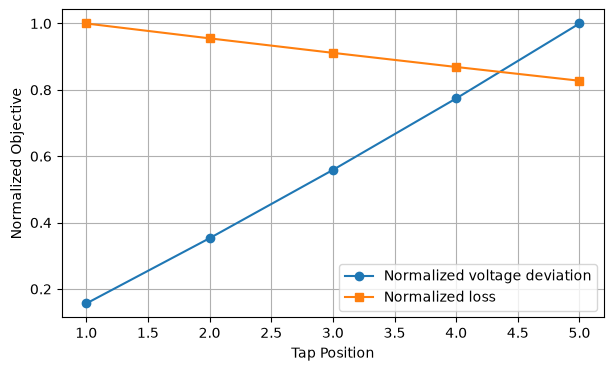

In [18]:
plot_data = tap_results_voltage.copy()

plot_data["Normalized_Loss"] = (
    tap_results_loss["Total_Loss"] / tap_results_loss["Total_Loss"].max()
)

plot_data["Normalized_Voltage_Deviation"] = (
    tap_results_voltage["Voltage_Deviation"]
    / tap_results_voltage["Voltage_Deviation"].max()
)

plt.figure(figsize=(7, 4))

plt.plot(
    plot_data["Tap_Position"],
    plot_data["Normalized_Voltage_Deviation"],
    marker="o",
    label="Normalized voltage deviation",
)

plt.plot(
    plot_data["Tap_Position"],
    plot_data["Normalized_Loss"],
    marker="s",
    label="Normalized loss",
)

plt.xlabel("Tap Position")
plt.ylabel("Normalized Objective")
plt.grid(True)
plt.legend()
plt.show()

## Tap Optimization Conclusion
- The optimal tap position depends on the selected optimization objective.
- **Voltage deviation optimization** selected **tap position 1**, resulting in the best overall voltage profile.
- **Loss optimization** selected **tap position 5**, resulting in the lowest network losses.
- The results highlight a trade-off between voltage quality and system losses.
- The implemented framework allows operators to automatically determine the tap position that best matches their operational priorities.



# 6. Collaboration and Conclusions

## Collaboration

Briefly go over:

- Git workflow
- Feature branches
- Pull requests
- Code reviews
- Testing and coverage 
- Division of work

## AI usage

Briefly explain AI tool usage + usefulness:

- As a learning tool
- Debugging
- Test writing
- Documentation
- Presentation preparation

Also mention that all generated output was reviewed and verified by the team.

## Final conclusion

Summarize the project:

- We built a working Python package
- We implemented graph and power flow computation functionality
- We applied it to practical grid analysis scenarios
- We worked using professional software engineering practices


In [19]:
# Maybe - show test coverage / quality checks

# run before presentation and save output
# !uv run pytest
# !uv run ruff check


# Backup / Extra Material

Use as an Appendix for the Q&A session.
Probably include our unit tests here in case they ask about them.
